In [ ]:
'''
Question -> Retrieve -> Retrieval Grader -> Relevant? -> Generate ->
Grounding Checker -> Answer Relevance Checker -> Final Answer
'''

'\nQuestion -> Retrieve -> Retrieval Grader -> Relevant? -> Generate -> \nGrounding Checker -> Answer Relevance Checker -> Final Answer\n'

In [ ]:
# Installing Library
!pip install -q \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langchain-huggingface \
faiss-cpu \
pandas

In [ ]:
# Imports
import os
import pandas as pd
from pathlib import Path
from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Embedding Model
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
#  loading the vectorstore
FAISS_PATH = (
    "/content/drive/MyDrive/legal_ai/vectorstores/legal_faiss"
)

In [ ]:
vectorstore = FAISS.load_local(
    FAISS_PATH,
    embeddings,
    allow_dangerous_deserialization=True
)

In [ ]:
# Retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5
    }
)

In [ ]:
import os
os.environ["OPENAI_API_KEY"] ="bedrock-api-key-YmVkcm9jay5hbWF6b25hd3MuY29tLz9BY3Rpb249Q2FsbFdpdGhCZWFyZXJUb2tlbiZYLUFtei1BbGdvcml0aG09QVdTNC1ITUFDLVNIQTI1NiZYLUFtei1DcmVkZW50aWFsPUFTSUFYNjZWV1o0S1IzVlZKR0xTJTJGMjAyNjA2MjAlMkZldS1ub3J0aC0xJTJGYmVkcm9jayUyRmF3czRfcmVxdWVzdCZYLUFtei1EYXRlPTIwMjYwNjIwVDA1MDEzN1omWC1BbXotRXhwaXJlcz00MzIwMCZYLUFtei1TZWN1cml0eS1Ub2tlbj1JUW9KYjNKcFoybHVYMlZqRUFVYUNtVjFMVzV2Y25Sb0xURWlSekJGQWlFQTVnblk0ZTR5b0RkM2tWSnpmYm03OGd2SFElMkIwU0tYckJBVjZDS2Z5OWNGQUNJQ3l4bDFwWHA4M1pObGFXbEJYZVQ2YXc4Wkc5OXY2WXVrU1gxdEJLUGllYUtxNERDTTclMkYlMkYlMkYlMkYlMkYlMkYlMkYlMkYlMkYlMkZ3RVFBQm9NTlRRM05URTVOalEzTlRBNUlnem9ZOSUyQmFyZkwwSUFmcXVza3FnZ083S2tteGlRMUpvaGNQWmtJZUslMkJlaTdvNmdOWkNKZjdNU2ZhRWJ6Z1FUMVZnMUlvUEsxU1ZwTFdscU1qdG9jWlc0QVdJcjJTV2VZbDFseGhIYlFHV1ZyNyUyRkhsTXI2d001YkkwaVJTaVhFJTJGQ3pjSGRLNGx3V0RZalozMFJKemdoUDQwJTJGSmYlMkJkeHd4WmdiTmFlMzVjN0dvdkRhRlNhbWtwJTJCRTU2QTlhV2ZLc1ZPb3hhdmNiaW53YVdra0wxQkRidzUlMkJwWGpMY3R3SXJzcHRTZ3Fqam0lMkJPbm4lMkIycjBhb0hMdkdmbkNYQ1I3cjU4VzdtSGFuOCUyRm9OT3hFdnNiRWdZVWRLN2YlMkJsQlF1bXZxbWRvaEsya1drNDZhOXBrOVpDVGVrdmNlZUxvVzhKMzRwckpOJTJCUXJJclJROTlaZm5TYnBsRXBkNHdOOEg1cjh4ODZsVGtVNSUyRnd4S1BsQjRWeTVJTldZVFglMkJGUlA4NUZVcEpJQlZWYmtPQUNteE5Xc1UwTHhadG9tSG4xN0FnSXhiV3JOdEMzTE1mMzZzTUI0cVhyMW5HTUloYTNkUDBCTFV4R1F0YWRtbUJqVEFuMmxIWWZBVzhndVBkbWNFVkxoS3ZhdTNuR0o4Nks4UmZmQ3IyNHlJWHdrOTZPQUVLcGkxejUwMjdHdWF6djZPUnlXeElSNlUwNmpDYnZkalJCanJlQW9USE9JaUxoVlY5ZW0waUlCaHMxdiUyRlYlMkZhb2YwWkplUm5zVnNvJTJGMU1ta3RHQmhHamk1S3c0T2VRaWNHamhydnlRdFlOVXhQUzlEOU9lRE13Vmw2dTVnR1FRS0NVcXMySEFnMkFyY1BtM3pySmwwWkNNYjRoNElkbUMlMkZHJTJCZ2NVamdLMVpVckRjYnUlMkI1bXFvZTFJeXM4NjZycmd5R3ZaZlpHdlFtV3RPeDNkSDM0Ulh0aFo2QjdqTXZlYkhCdloxZG11V3YwNnhxY2JTb0FiTHoxZ1l0UDdMd1FBc1JzMmJxc2FTaFduS0RISldqRU9KRWJOcFVNSExVQWpsZHcxRmdJQWhqN09QYzBTQ2IzY0lBZ0VITkpDSHNPUFZHSHpGJTJCM3JYY2NNS0ZSZU5hMkFaYm4xTXlIdHM1M1JmQ3U0eVl0M1RpVlc5NnFqa3Y3UjZaREhMQ2xGbUhWbFlDTDVibkJ1S1I3M093QXF0RlYzd1pBOHIwdUxNJTJGNWZYTm5PTkRpeGdjRGx5SW5XemxFOCUyQnNJaHdKQ1BHUklBOWdWb0FMQW5sRm9lamNwMGlTS3NFNHFBYVQ1c05TYlFTNmpjVnM2JTJCVkNDNXlldlo5YkN2NXB0YU0mWC1BbXotU2lnbmF0dXJlPWE4NDczMGMxNmQ4YWFkNzA1NDliYThjZGYxNThjNGYzOGNjMTJkYzFmY2M0MTdiMDAxM2Q0NWMzZGJjOTUzYzkmWC1BbXotU2lnbmVkSGVhZGVycz1ob3N0JlZlcnNpb249MQ=="
os.environ["OPENAI_BASE_URL"]= "https://bedrock-mantle.eu-north-1.api.aws/v1"


In [ ]:
llm = ChatOpenAI(
    model="openai.gpt-oss-120b",
    temperature=0
)

In [ ]:
response = llm.invoke(
    "What is Retrieval Augmented Generation?"
)

print(response.content)

## Retrieval‑Augmented Generation (RAG) – at a Glance  

| Aspect | What it means | Why it matters |
|--------|----------------|----------------|
| **Core idea** | Combine a **retriever** (searches an external knowledge store) with a **generator** (a large language model, LLM) so the model can ground its output in up‑to‑date, factual information. | Pure LLMs are limited to the knowledge baked into their parameters and can hallucinate. RAG lets them “look up” the latest data, citations, or domain‑specific facts. |
| **Typical pipeline** | 1️⃣ **Query encoding** – turn the user prompt into a vector (or a set of keywords). <br>2️⃣ **Retrieval** – fetch the *k* most relevant passages/documents from a corpus (Wikipedia, internal docs, API results, etc.). <br>3️⃣ **Augmentation** – inject the retrieved texts into the generator’s context (as a prompt, as encoder inputs, or via cross‑attention). <br>4️⃣ **Generation** – the LLM produces a response that is conditioned on both the original query

### Building Self RAG Components


Ambiguity Checker function


In [ ]:
ambiguity_prompt = ChatPromptTemplate.from_template(
"""
You are a legal question evaluator.

Question:
{question}

Determine whether the question is specific enough
to be answered from a collection of contracts.

Examples:

Who is the CEO?
→ no

What is the stock price?
→ no

What is the governing law of the ADMA Manufacturing Agreement?
→ yes

What confidentiality obligations exist?
→ yes

Reply ONLY:

yes

or

no
"""
)

In [ ]:
ambiguity_checker = ambiguity_prompt | llm | StrOutputParser()

In [ ]:
def check_question_clarity(question):

    result = ambiguity_checker.invoke({
        "question": question
    })

    return result.lower().strip()

Retrieval Grader Function

In [ ]:
retrieval_grader_prompt = ChatPromptTemplate.from_template(
"""
You are a legal retrieval evaluator.

Question:
{question}

Retrieved Context:
{context}

Determine whether the retrieved context
contains sufficient evidence to answer
the question accurately.

Rules:

1. The answer must be directly supported.
2. The answer must not require guessing.
3. If the question is ambiguous, answer NO.
4. If multiple entities exist and the question
does not identify which one, answer NO.

Reply ONLY:

yes

or

no
"""
)

In [ ]:
retrieval_grader = retrieval_grader_prompt | llm | StrOutputParser()


In [ ]:
def grade_retrieval(question, docs):

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    result = retrieval_grader.invoke({
        "question": question,
        "context": context
    })

    return result.lower().strip()

Sufficient Evidence Checker

In [ ]:
retrieval_sufficiency_prompt = ChatPromptTemplate.from_template(
"""
You are a legal evidence evaluator.

Question:
{question}

Retrieved Context:
{context}

Decide whether the retrieved context contains sufficient evidence
to answer the question reliably.

Rules:
- If the answer is directly supported, answer YES
- If the evidence is weak, incomplete, or ambiguous, answer NO
- If there are multiple possible answers and the question does not specify which one, answer NO
- Do not guess

Reply ONLY with:
yes
or
no
"""
)

In [ ]:
retrieval_sufficiency_chain =  retrieval_sufficiency_prompt | llm | StrOutputParser()


In [ ]:
def check_retrieval_sufficiency(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = retrieval_sufficiency_chain.invoke({
        "question": question,
        "context": context
    })
    return result.strip().lower()

Answer Generator

In [ ]:
answer_prompt = ChatPromptTemplate.from_template(
"""
You are a legal contract assistant.

Answer ONLY using the supplied context.

If the answer is not available,
say:

Information not found in retrieved contracts.

Question:
{question}

Context:
{context}
"""
)

In [ ]:
answer_chain = answer_prompt | llm | StrOutputParser()


In [ ]:
def generate_answer(question, docs):

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return answer_chain.invoke({
        "question": question,
        "context": context
    })

Grounding Grader

In [ ]:
grounding_prompt = ChatPromptTemplate.from_template(
"""
You are a legal fact checker.

Retrieved Context:
{context}

Generated Answer:
{answer}

Is the answer fully supported
by the retrieved context?

Reply ONLY:

yes

or

no
"""
)

In [ ]:
grounding_grader =  grounding_prompt | llm | StrOutputParser()


In [ ]:
def grade_grounding(answer, docs):

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    result = grounding_grader.invoke({
        "answer": answer,
        "context": context
    })

    return result.lower().strip()

Answer Relevance Grader

In [ ]:
answer_grader_prompt = ChatPromptTemplate.from_template(
"""
Question:
{question}

Generated Answer:
{answer}

Does the answer address
the user's question?

Reply ONLY: yes or no

"""
)

In [ ]:
answer_grader = answer_grader_prompt | llm | StrOutputParser()


In [ ]:
def grade_answer(question, answer):

    result = answer_grader.invoke({
        "question": question,
        "answer": answer
    })

    return result.lower().strip()

Question Router

In [ ]:
# =====================================================
# SECTION 8.1 - Question Router
# =====================================================

question_router_prompt = ChatPromptTemplate.from_template(
"""
You are a legal question router.

Classify the question into exactly one of these labels:

- retrieve: the question should be answered using the contract corpus
- direct: the question can be answered without contract evidence
- clarify: the question is underspecified or ambiguous and needs more detail

Rules:
- "Who is the CEO?" -> clarify
- "What is the stock price?" -> clarify
- "Who won the FIFA World Cup?" -> direct
- "What confidentiality obligations exist?" -> retrieve
- "What is the governing law of the ADMA Manufacturing Agreement?" -> retrieve

Return ONLY one label:
retrieve
direct
clarify

Question:
{question}
"""
)





In [ ]:
question_router_chain = question_router_prompt | llm | StrOutputParser()

In [ ]:
def route_question(question):
    result = question_router_chain.invoke({"question": question})
    return result.strip().lower()

Direct Answer Node

In [ ]:
direct_answer_prompt = ChatPromptTemplate.from_template(
"""
You are a helpful assistant.

Answer the question directly and concisely.

Use general knowledge if the question is not about contracts.
If the question is ambiguous, say what detail is missing.
If you are not certain, say you do not know.

Question:
{question}
"""
)

In [ ]:
direct_answer_chain = direct_answer_prompt | llm | StrOutputParser()

In [ ]:
def generate_direct_answer(question):
    result = direct_answer_chain.invoke({"question": question})
    return result.strip()

Query Rewriter

In [ ]:
query_rewrite_prompt = ChatPromptTemplate.from_template(
"""
You are a legal query rewriter.

Original Question:
{question}

Retrieved Context:
{context}

Rewrite the question to make it more specific and easier to answer from contracts.

Rules:
- Keep the legal intent
- Add specificity if needed
- If the question is ambiguous, resolve it if possible from context
- If it cannot be resolved, keep it clear and focused
- Return only the rewritten question, no explanation
"""
)

In [ ]:
query_rewrite_chain =  query_rewrite_prompt | llm | StrOutputParser()

In [ ]:
def rewrite_question(question, docs):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = query_rewrite_chain.invoke({
        "question": question,
        "context": context
    })
    return result.strip()

Answer Reviser

In [ ]:
answer_revise_prompt = ChatPromptTemplate.from_template(
"""
You are a legal answer reviser.

Question:
{question}

Retrieved Context:
{context}

Previous Answer:
{answer}

The previous answer was not grounded or not useful.

Revise the answer so that it is fully supported by the context.
If no reliable answer can be made, say:
Information not found in retrieved contracts.

Return only the revised answer.
"""
)

In [ ]:
answer_revise_chain = answer_revise_prompt | llm | StrOutputParser()



In [ ]:
def revise_answer(question, docs, answer):
    context = "\n\n".join(doc.page_content for doc in docs)
    result = answer_revise_chain.invoke({
        "question": question,
        "context": context,
        "answer": answer
    })
    return result.strip()

Build Self-RAG Pipeline

In [ ]:
# =====================================================
# SECTION 9 - Self-RAG Pipeline with Retry Loop
# =====================================================

def self_rag(question, max_retries=3):

    original_question = question
    current_question = question

    print("=" * 80)
    print("ORIGINAL QUESTION")
    print(original_question)
    print("=" * 80)

    # -------------------------------------------------
    # ROUTER
    # -------------------------------------------------

    route = route_question(current_question)

    print(f"\nROUTE DECISION: {route}")

    if route == "clarify":

        return {
            "question": original_question,
            "final_question": current_question,
            "attempts_used": 0,
            "answer":
            "Question is ambiguous or underspecified. Please provide more specific details.",
            "sources": [],
            "status": "clarify_needed"
        }

    if route == "direct":

        answer = generate_direct_answer(current_question)

        return {
            "question": original_question,
            "final_question": current_question,
            "attempts_used": 0,
            "answer": answer,
            "sources": [],
            "status": "direct_answer"
        }

    # -------------------------------------------------
    # RETRIEVAL PATH
    # -------------------------------------------------

    attempt = 0
    docs = []
    answer = ""

    while attempt < max_retries:

        attempt += 1

        print("\n")
        print("=" * 80)
        print(f"ATTEMPT {attempt}")
        print("=" * 80)

        print("\nCURRENT QUESTION:")
        print(current_question)

        # ---------------------------------------------
        # RETRIEVE
        # ---------------------------------------------

        docs = retriever.invoke(current_question)

        print(f"\nRetrieved Documents: {len(docs)}")

        # ---------------------------------------------
        # EVIDENCE CHECK
        # ---------------------------------------------

        sufficiency = check_retrieval_sufficiency(
            current_question,
            docs
        )

        print(f"Evidence Check: {sufficiency}")

        if sufficiency != "yes":

            print("Evidence insufficient")

            if attempt < max_retries:

                rewritten_question = rewrite_question(
                    current_question,
                    docs
                )

                print("\nQUESTION REWRITE")

                print(f"OLD: {current_question}")

                print(f"NEW: {rewritten_question}")

                current_question = rewritten_question

                continue

            return {

                "question": original_question,
                "final_question": current_question,
                "attempts_used": attempt,

                "answer":
                "Information not found in retrieved contracts.",

                "sources": [],

                "status":
                "retrieval_failed"
            }

        # ---------------------------------------------
        # GENERATE ANSWER
        # ---------------------------------------------

        answer = generate_answer(
            current_question,
            docs
        )

        print("\nGENERATED ANSWER")
        print(answer[:500])

        # ---------------------------------------------
        # GROUNDING CHECK
        # ---------------------------------------------

        grounding = grade_grounding(
            answer,
            docs
        )

        print(f"\nGrounding Check: {grounding}")

        if grounding != "yes":

            print("Grounding failed")

            if attempt < max_retries:

                revised_answer = revise_answer(
                    current_question,
                    docs,
                    answer
                )

                print("\nANSWER REVISED")
                print(revised_answer[:500])

                answer = revised_answer

                grounding = grade_grounding(
                    answer,
                    docs
                )

                print(
                    f"\nGrounding After Revision: "
                    f"{grounding}"
                )

                if grounding == "yes":

                    relevance = grade_answer(
                        current_question,
                        answer
                    )

                    print(
                        f"Relevance After Revision: "
                        f"{relevance}"
                    )

                    if relevance == "yes":

                        return {

                            "question":
                            original_question,

                            "final_question":
                            current_question,

                            "attempts_used":
                            attempt,

                            "answer":
                            answer,

                            "sources":
                            [
                                doc.metadata["source"]
                                for doc in docs
                            ],

                            "status":
                            "success"
                        }

                continue

            return {

                "question":
                original_question,

                "final_question":
                current_question,

                "attempts_used":
                attempt,

                "answer":
                "Generated answer was not grounded in retrieved evidence.",

                "sources":
                [],

                "status":
                "grounding_failed"
            }

        # ---------------------------------------------
        # RELEVANCE CHECK
        # ---------------------------------------------

        relevance = grade_answer(
            current_question,
            answer
        )

        print(f"\nRelevance Check: {relevance}")

        if relevance != "yes":

            print("Answer not relevant")

            if attempt < max_retries:

                rewritten_question = rewrite_question(
                    current_question,
                    docs
                )

                print("\nQUESTION REWRITE")

                print(f"OLD: {current_question}")

                print(f"NEW: {rewritten_question}")

                current_question = rewritten_question

                continue

            return {

                "question":
                original_question,

                "final_question":
                current_question,

                "attempts_used":
                attempt,

                "answer":
                "Generated answer did not answer the question.",

                "sources":
                [],

                "status":
                "answer_failed"
            }

        # ---------------------------------------------
        # SUCCESS
        # ---------------------------------------------

        print("\nSUCCESS")

        return {

            "question":
            original_question,

            "final_question":
            current_question,

            "attempts_used":
            attempt,

            "answer":
            answer,

            "sources":
            [
                doc.metadata["source"]
                for doc in docs
            ],

            "status":
            "success"
        }

    return {

        "question":
        original_question,

        "final_question":
        current_question,

        "attempts_used":
        attempt,

        "answer":
        "Unable to generate a reliable answer after retries.",

        "sources":
        [],

        "status":
        "failed_after_retries"
    }

In [ ]:
# Evaluation
test_questions = [

    "Who is the CEO of the company?",

    "What is the stock price?",

    "Who won the FIFA World Cup?",

    "What confidentiality obligations exist?",

    "What indemnification obligations exist?"
]

In [ ]:
for q in test_questions:

    print("\n")
    print("#" * 100)
    print(q)

    result = self_rag(q)

    print("\nSTATUS:")
    print(result["status"])

    print("\nATTEMPTS:")
    print(result["attempts_used"])

    print("\nANSWER:")
    print(result["answer"])

    print("\nSOURCES:")
    print(result["sources"])



####################################################################################################
Who is the CEO of the company?
ORIGINAL QUESTION
Who is the CEO of the company?

ROUTE DECISION: clarify

STATUS:
clarify_needed

ATTEMPTS:
0

ANSWER:
Question is ambiguous or underspecified. Please provide more specific details.

SOURCES:
[]


####################################################################################################
What is the stock price?
ORIGINAL QUESTION
What is the stock price?

ROUTE DECISION: clarify

STATUS:
clarify_needed

ATTEMPTS:
0

ANSWER:
Question is ambiguous or underspecified. Please provide more specific details.

SOURCES:
[]


####################################################################################################
Who won the FIFA World Cup?
ORIGINAL QUESTION
Who won the FIFA World Cup?

ROUTE DECISION: direct

STATUS:
direct_answer

ATTEMPTS:
0

ANSWER:
The question is ambiguous—there have been many FIFA World Cup tournaments.

Lang Graph

In [ ]:
!pip install -q langgraph grandalf

In [ ]:
from typing import TypedDict

from langgraph.graph import (
    StateGraph,
    END
)

from IPython.display import (
    Image,
    display
)

In [ ]:
class GraphState(TypedDict):

    question: str

    answer: str

    status: str

In [ ]:
builder = StateGraph(GraphState)

In [ ]:

builder.add_node(
    "route_question",
    lambda state: state
)

builder.add_node(
    "direct_answer",
    lambda state: state
)

builder.add_node(
    "retrieve",
    lambda state: state
)

builder.add_node(
    "check_evidence",
    lambda state: state
)

builder.add_node(
    "rewrite_query",
    lambda state: state
)

builder.add_node(
    "generate_answer",
    lambda state: state
)

builder.add_node(
    "check_grounding",
    lambda state: state
)

builder.add_node(
    "revise_answer",
    lambda state: state
)

builder.add_node(
    "check_relevance",
    lambda state: state
)

builder.add_node(
    "clarify_user",
    lambda state: state
)

In [ ]:
builder.set_entry_point(
    "route_question"
)

# -----------------------------
# Direct Path
# -----------------------------

builder.add_edge(
    "route_question",
    "direct_answer"
)

builder.add_edge(
    "direct_answer",
    END
)

# -----------------------------
# Clarify Path
# -----------------------------

builder.add_edge(
    "route_question",
    "clarify_user"
)

builder.add_edge(
    "clarify_user",
    END
)

# -----------------------------
# Retrieval Path
# -----------------------------

builder.add_edge(
    "route_question",
    "retrieve"
)

builder.add_edge(
    "retrieve",
    "check_evidence"
)

# Retrieval Retry Loop

builder.add_edge(
    "check_evidence",
    "rewrite_query"
)

builder.add_edge(
    "rewrite_query",
    "retrieve"
)

# Successful Retrieval

builder.add_edge(
    "check_evidence",
    "generate_answer"
)

# Grounding

builder.add_edge(
    "generate_answer",
    "check_grounding"
)

# Grounding Retry Loop

builder.add_edge(
    "check_grounding",
    "revise_answer"
)

builder.add_edge(
    "revise_answer",
    "check_grounding"
)

# Successful Grounding

builder.add_edge(
    "check_grounding",
    "check_relevance"
)

# Final Success

builder.add_edge(
    "check_relevance",
    END
)

In [ ]:
graph = builder.compile()

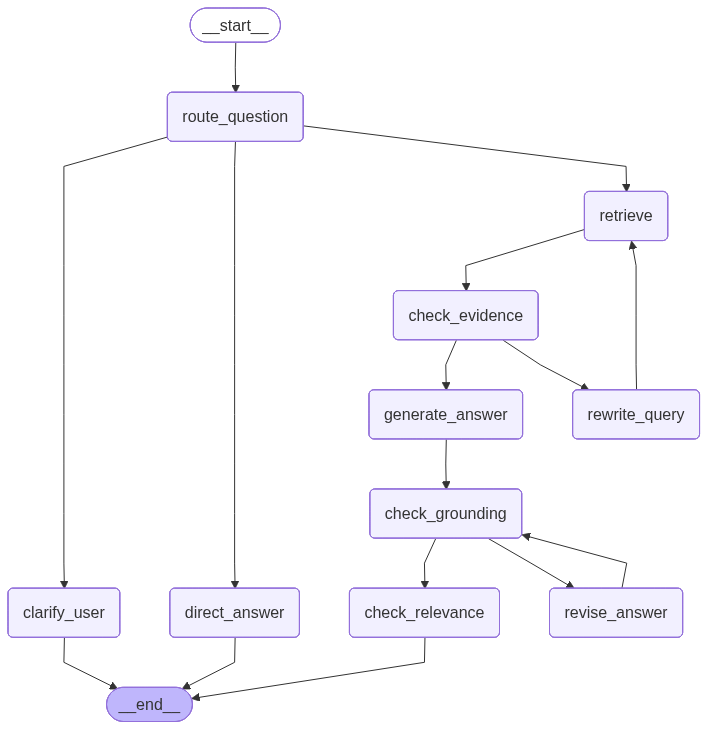

In [ ]:
display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [ ]:
test_questions = [

    "What happens when a contract ends?",

    "When can the agreement be cancelled?",

    "What liabilities survive termination?",

    "What happens if a party wants out?",

    "Explain all obligations under the agreement",

    "List every confidentiality requirement",

    "Describe all indemnification duties",

    "Summarize every important legal obligation"
]

In [ ]:
for q in test_questions:

    print("\n")
    print("#" * 100)
    print(q)

    result = self_rag(q)

    print("\nSTATUS:")
    print(result["status"])

    print("\nATTEMPTS:")
    print(result["attempts_used"])

    print("\nANSWER:")
    print(result["answer"])

    print("\nSOURCES:")
    print(result["sources"])



####################################################################################################
What happens when a contract ends?
ORIGINAL QUESTION
What happens when a contract ends?

ROUTE DECISION: direct

STATUS:
direct_answer

ATTEMPTS:
0

ANSWER:
When a contract ends, the parties’ contractual obligations generally cease, and they must:

1. **Perform any final duties** – such as delivering remaining goods, completing work, or making final payments.
2. **Settle accounts** – pay any outstanding amounts, issue refunds, or handle penalties specified for termination.
3. **Return or retain property** – return any borrowed items, confidential information, or intellectual‑property rights as required.
4. **Observe post‑termination clauses** – such as confidentiality, non‑competition, or warranty obligations that survive the contract’s term.
5. **Consider renewal or extension** – if the contract includes an option to renew, the parties may negotiate a new agreement before the current